# 圓餅圖 Pie Chart：

## 開場活動：把 100 元想成一個完整披薩

假設午餐總共花 100 元：主餐 60 元、配菜 25 元、飲料 15 元。整個圓代表這 **100 元**，不是代表「三個品項」，也不是代表「這一天所有支出」。主餐占 60/100，因此拿走 60% 的圓。

| 部分 | 金額 | 占比的計算 | 百分比 | 圓心角 |
|---|---:|---|---:|---:|
| 主餐 | 60 | 60 ÷ 100 | 60% | 216° |
| 配菜 | 25 | 25 ÷ 100 | 25% | 90° |
| 飲料 | 15 | 15 ÷ 100 | 15% | 54° |
| 合計 | 100 | 100 ÷ 100 | 100% | 360° |

**占比 = 這一類的數值 ÷ 全部類別的合計。百分比 = 占比 × 100。角度 = 占比 × 360。**

圓餅的半徑相同時，角度越大，扇形面積也越大。不必自己寫三角函數，繪圖工具會幫我們切好；我們的責任是交給它正確的數字。數字可以是金額、次數、分鐘、公斤，但同一個圓內要用同一種單位。


In [1]:
# 這裡先用純 Python 手算，不需要安裝繪圖套件。
amounts_list = [60, 25, 15]
total = sum(amounts_list)
for amount in amounts_list:
    fraction = amount / total
    print(f'{amount} 元 → {fraction:.2f} → {fraction * 100:.1f}% → {fraction * 360:.1f} 度')


60 元 → 0.60 → 60.0% → 216.0 度
25 元 → 0.25 → 25.0% → 90.0 度
15 元 → 0.15 → 15.0% → 54.0 度


## 畫之前先問四件事：這個圓真的湊得起來嗎？

1. **整體是誰？** 例如「某人 9 月已記錄的生活支出」，要交代對象、期間與範圍。
2. **分類會重複嗎？** 「外食」和「午餐」可能重複；若把同一筆午餐同時計入兩類，就重算了。互斥的意思是同一筆只能歸一類。
3. **有漏掉嗎？** 若只拿房租與餐費作圖，整個圓只代表這兩類的合計，不能標成全部生活費。完整的意思是範圍內的資料都有位置。
4. **這些數字能相加嗎？** 金額可以加金額，分鐘可以加分鐘；不要把 8 小時、200 元與 5 人一起塞進一個圓。

## 常用參數

不必一次背完；遇到範例時再回來查。

| 參數 | 先這樣理解 | 在哪裡用到 |
|---|---|---|
| `labels` | 每一塊的名稱，順序對應數值 | 01 |
| `autopct='%1.1f%%'` | 百分比顯示到一位小數；`%%` 印出百分號 | 01、02 |
| `startangle=90` | 從上方開始放第一塊 | 02 |
| `counterclock=False` | 改成順時針排列 | 02 |
| `colors` | 每一塊的顏色清單 | 04、11 |
| `explode` | 每塊離開圓心的距離比例；通常只稍微突出重點 | 05 |
| `wedgeprops` | 扇形的樣式字典 | 04、07 |
| `textprops` | 文字的樣式字典 | 04 |
| `pctdistance` | 百分比文字距離圓心的位置，半徑比例 | 07 |
| `labeldistance` | 類別文字距離圓心的位置 | 01 |

`ax.pie` 會把數值依總和換成比例，所以通常直接交給它 60、25、15，不必先換成 0.6、0.25、0.15。這個自動正規化功能只會做數學運算，**不會知道你有沒有漏掉某一類**。本課進度環一律明列「已完成」與「未完成」，不靠半個圓猜剩餘量。


# 第一部分：Matplotlib 做圓餅圖


### 範例：月底錢花去哪裡

**Matplotlib**　|　資料：[datasets/01_每月生活支出.csv](datasets/01_每月生活支出.csv)  

月底總覺得小錢花太多。先把帳本整理出來，看看最大項究竟是飲食、住屋還是交通。這張圖能用於家庭記帳交接，也能幫助你決定下一步該查哪一類明細。

**一列代表：** 小安某月某一支出類別的合計，單位為元。  
**整個圓的範圍與分母：** 小安該月六類已記錄支出合計 30,000 元；不含未記錄消費與儲蓄。

In [12]:
import pandas as pd

df = pd.read_csv("./datasets/每月生活支出.csv", encoding="utf-8-sig")
s = df.set_index('類別')['金額'] # 將「類別」設為索引，並取出「金額」欄位成為 Series
s

類別
房租      12000
餐費       9000
交通       2400
水電瓦斯     1800
休閒       3000
日用品      1800
Name: 金額, dtype: int64

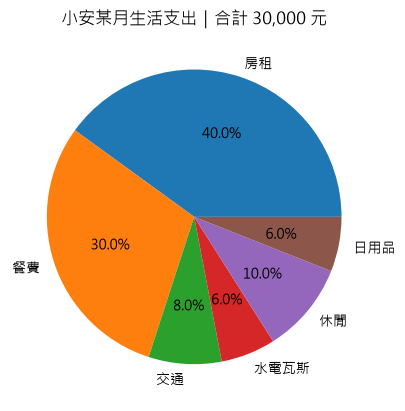

In [15]:
import matplotlib.pyplot as plt

with plt.style.context("default"):
	# 中文設定
	plt.rcParams["font.family"] = "Microsoft JhengHei" # Windows 微軟正黑體
	plt.rcParams["axes.unicode_minus"] = False # 避免負號顯示異常
	fig, ax = plt.subplots(figsize=(4, 4), layout='constrained')
	# 繪製圓餅圖：
    # - s: 各類別數值資料（Pandas Series）
    # - labels=s.index: 扇形區塊的標籤文字（取自 Series 的索引）
    # - autopct='%1.1f%%': 在各扇形內顯示數值所佔百分比，格式化至小數點後第一位
    # - labeldistance=1.1: 標籤文字距離圓心的相對距離（1.0 為圓周邊緣，>1 位於外部）
	ax.pie(s, labels=s.index, autopct='%1.1f%%', labeldistance=1.1)
	ax.set_title(f'小安某月生活支出｜合計 {s.sum():,.0f} 元')
	plt.show()

### 範例：飲料喝得多不等於花得多

**Matplotlib**　|　資料：[datasets/03_一週飲料明細.csv](datasets/03_一週飲料明細.csv)  


你可能一週買四次水、四次咖啡、四次手搖飲，但三者花費並不相同。若想控制飲料預算，就要問金額，而不是只問購買次數。這是店面與行政報表很常見的口徑差異。

**一列代表：** 小安一次購買一杯／瓶飲料的紀錄；本例每列剛好一杯／瓶。  
**整個圓的範圍與分母：** 一週已記錄飲料支出 530 元。

In [18]:
import pandas as pd

df = pd.read_csv("./datasets/一週飲料明細.csv", encoding="utf-8-sig")
s = df.groupby('類別')['金額'].sum().sort_values(ascending=False)
s

類別
手搖飲     270
超商咖啡    180
瓶裝水      80
Name: 金額, dtype: int64

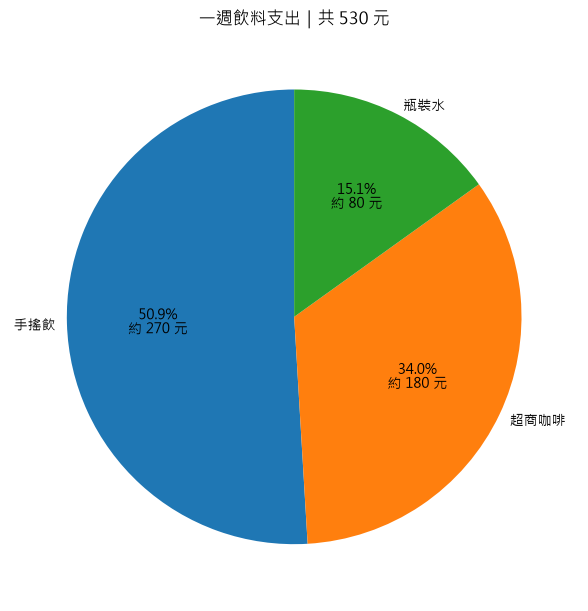

In [ ]:
import matplotlib.pyplot as plt

total = s.sum()

with plt.style.context("default"):
    # 中文設定
    plt.rcParams["font.family"] = "Microsoft JhengHei"
    plt.rcParams["axes.unicode_minus"] = False

    fig, ax = plt.subplots(figsize=(8, 6), layout='constrained')
    
    # 繪製圓餅圖並解包接收回傳的三個物件：
    # - patches: 各個扇形區塊的 Patch 物件清單
    # - texts: 圓餅圖外圍的標籤文字物件清單（即 s.index 的文字）
    # - autotexts: 圓餅圖內部自動產生的百分比文字物件清單
    # - startangle=90: 第一個扇區從 90 度（正上方 12 點鐘方向）開始逆時針繪製
    patches, texts, autotexts = ax.pie(
        s, 
        labels=s.index, 
        autopct='%1.1f%%', 
        labeldistance=1.05,
        startangle=90
    )
    ax.set_title(f'一週飲料支出｜共 {total:,.0f} 元')
    # 遍歷內部的百分比文字物件與原始金額數值
    for autotext, val in zip(autotexts, s):
        pct_text = autotext.get_text() # 取得目前產生的百分比字串（例如 "42.9%"）
        autotext.set_text(f'{pct_text}\n約 {val:,.0f} 元') # 將原本的百分比換行補上實際金額，並格式化為千分位整數
    plt.show()

### 範例：每月訂閱小額加起來多少

**Matplotlib**　|　資料：[datasets/04_每月訂閱費.csv](datasets/04_每月訂閱費.csv)  
獨立範例：[examples/04_每月訂閱小額加起來多少.py](examples/04_每月訂閱小額加起來多少.py)



單項看起來只要一兩百元，多項自動扣款加起來就有感。這張圖可用於整理家庭固定支出；上班後也能用同樣方法整理店裡固定的清潔、音樂與設備租用費。服務名稱與價格均為虛構。

**一列代表：** 一項虛構服務的月費，均已換成每月元數。  
**整個圓的範圍與分母：** 六項虛構訂閱服務的每月費用合計 1,176 元。

In [33]:
import pandas as pd

df = pd.read_csv("./datasets/每月訂閱費.csv", encoding="utf-8-sig")
s = df.set_index('服務')['月費'].sort_values(ascending=False)
s

服務
運動課    299
食譜課    250
影音甲    199
雜誌     180
音樂乙    149
有聲書     99
Name: 月費, dtype: int64

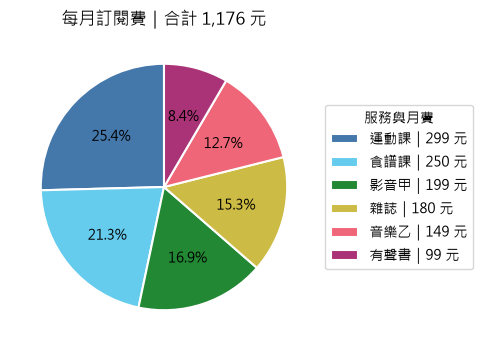

In [37]:
import matplotlib.pyplot as plt

colors = ['#4477AA', '#66CCEE', '#228833', '#CCBB44', '#EE6677', '#AA3377']
legend_labels = [f'{name}｜{value:,.0f} 元' for name, value in s.items()]

with plt.style.context("default"):
	# 中文設定
	plt.rcParams["font.family"] = "Microsoft JhengHei" # Windows 微軟正黑體
	plt.rcParams["axes.unicode_minus"] = False # 避免負號顯示異常
	fig, ax = plt.subplots(figsize=(6, 4))
	wedges, texts, autotexts = ax.pie(
		s, colors=colors, autopct='%1.1f%%', startangle=90,
		wedgeprops={'edgecolor':'white', 'linewidth':1.5},
		textprops={'fontsize':10})
	ax.legend(wedges, legend_labels, title='服務與月費',
			loc='center left', bbox_to_anchor=(1, 0.5))
	ax.set_title(f'每月訂閱費｜合計 {s.sum():,.0f} 元')
	plt.show()

### 範例：外送這一單到底付了什麼

**Matplotlib**　|　資料：[datasets/05_外送帳單組成.csv](datasets/05_外送帳單組成.csv)  
獨立範例：[examples/05_外送這一單到底付了什麼.py](examples/05_外送這一單到底付了什麼.py)

點餐畫面看到 220 元，結帳卻是 300 元。把帳單拆成餐點、外送與服務費，才能清楚說出多付在哪裡。生活上可以比較自取；櫃檯工作也常需要向客人解釋帳單。

**一列代表：** 一張虛構訂單的一種費用，沒有折扣或退款。  
**整個圓的範圍與分母：** 同一張外送訂單付款合計 300 元。

In [40]:
import pandas as pd

df = pd.read_csv("./datasets/外送帳單組成.csv", encoding="utf-8-sig")
s = df.set_index('項目')['金額']
s

項目
餐點     220
外送費     60
服務費     20
Name: 金額, dtype: int64

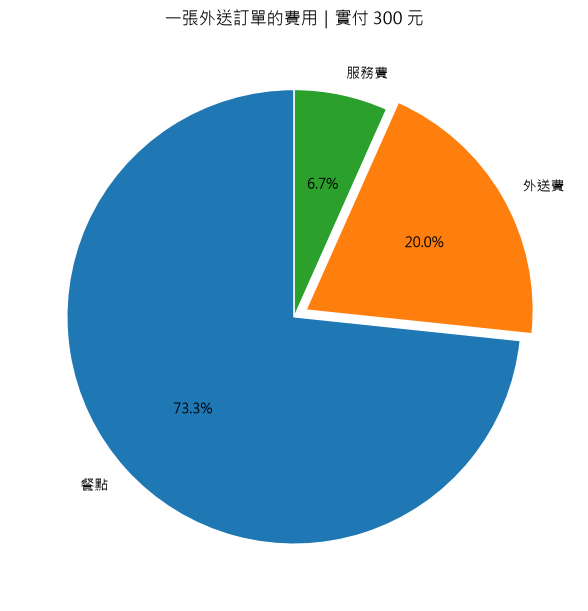

In [41]:
import matplotlib.pyplot as plt

explode = [0, 0.06, 0]

with plt.style.context("default"):
	# 中文設定
	plt.rcParams["font.family"] = "Microsoft JhengHei" # Windows 微軟正黑體
	plt.rcParams["axes.unicode_minus"] = False # 避免負號顯示異常
	fig, ax = plt.subplots(figsize=(8, 6), layout='constrained')
	ax.pie(s, labels=s.index, autopct='%1.1f%%', explode=explode,
		startangle=90, wedgeprops={'edgecolor':'white'})
	ax.set_title(f'一張外送訂單的費用｜實付 {s.sum():,.0f} 元')
	plt.show()

### 範例：占比升高但真的花更多嗎

**Matplotlib**　|　資料：[datasets/08_兩月採買支出.csv](datasets/08_兩月採買支出.csv)  
獨立範例：[examples/08_占比升高但真的花更多嗎.py](examples/08_占比升高但真的花更多嗎.py)

家人看到蔬果占比變大，以為你買得更貴。其實其他項目減少更多，也會讓蔬果的占比上升。這類誤會在月報與業績報告中很常見，必須同時查看金額與比例。

**一列代表：** 一個月份的一類採買金額；兩月使用相同分類。  
**整個圓的範圍與分母：** 每個圓各自代表該月採買總額；一月 10,000 元，二月 8,000 元。

In [43]:
import pandas as pd

df = pd.read_csv("./datasets/兩月採買支出.csv", encoding="utf-8-sig")
order = ['主食','蔬果','肉蛋','其他']
# 將資料由長表格轉為寬表格，並依指定清單重新排列列索引（行）的順序
wide = df.pivot(index='類別', columns='月份', values='金額').reindex(order)
wide

月份,一月,二月
類別,,
主食,2000,1600
蔬果,3000,2800
肉蛋,3500,2400
其他,1500,1200


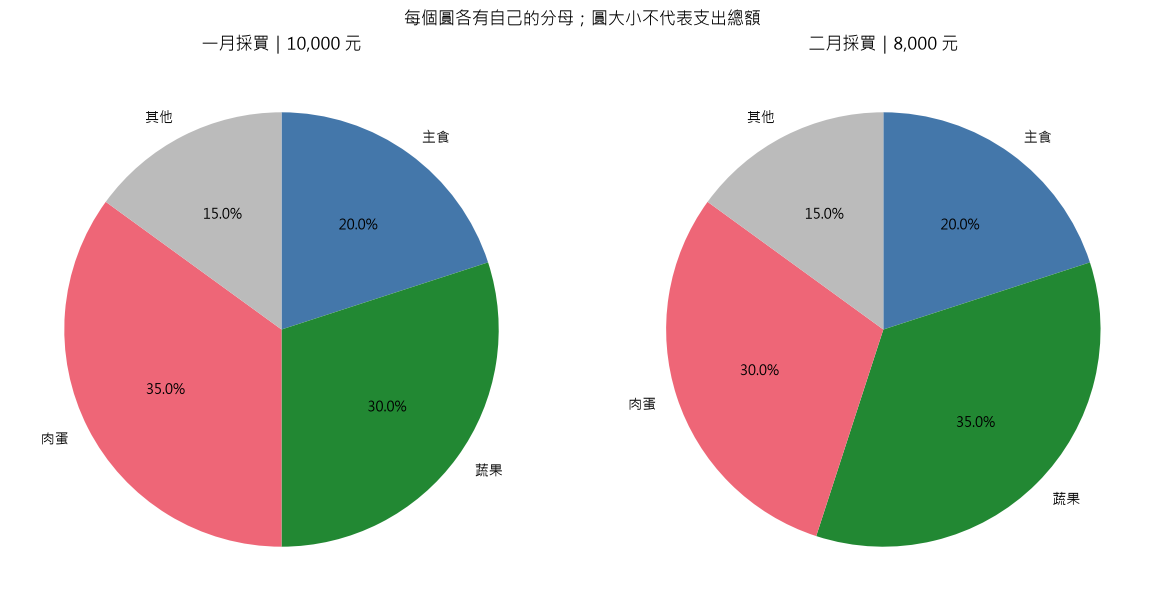

In [44]:
import matplotlib.pyplot as plt

color_map = {'主食':'#4477AA','蔬果':'#228833','肉蛋':'#EE6677','其他':'#BBBBBB'}

with plt.style.context("default"):
	# 中文設定
	plt.rcParams["font.family"] = "Microsoft JhengHei" # Windows 微軟正黑體
	plt.rcParams["axes.unicode_minus"] = False # 避免負號顯示異常
	fig, axes = plt.subplots(1, 2, figsize=(12, 6), layout='constrained')
	for ax, month in zip(axes, ['一月','二月']):
		s = wide[month]
		ax.pie(s, labels=s.index, autopct='%1.1f%%', startangle=90,
			counterclock=False, colors=[color_map[c] for c in s.index])
		ax.set_title(f'{month}採買｜{s.sum():,.0f} 元')
	fig.suptitle('每個圓各有自己的分母；圓大小不代表支出總額')
	plt.show()

# 第二部分：Seaborn 

Seaborn 本身完全沒有提供圓餅圖（Pie Chart）的 API（不存在 sns.pie() 或 sns.pieplot()）。

Seaborn 的作者與統計視覺化社群普遍認為，人眼對「角度」與「面積」的感知判斷力遠不如「長度」或「位置」，圓餅圖在比較類別多寡或微小差異時效果很差，因此官方提倡使用長條圖（Bar plot）取代，刻意未實作圓餅圖函式。
